In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency

# === PARTIE 1 : ACP ===

df = pd.read_csv("df_prepared.csv")
X_cr = pd.read_csv("X_cr.csv")
p = X_cr.shape[1]

# --- ACP ---
acp = PCA(n_components=p)
acp.fit(X_cr)

eigval = acp.explained_variance_
eigval_ratio = acp.explained_variance_ratio_
cumsum = np.cumsum(eigval_ratio)

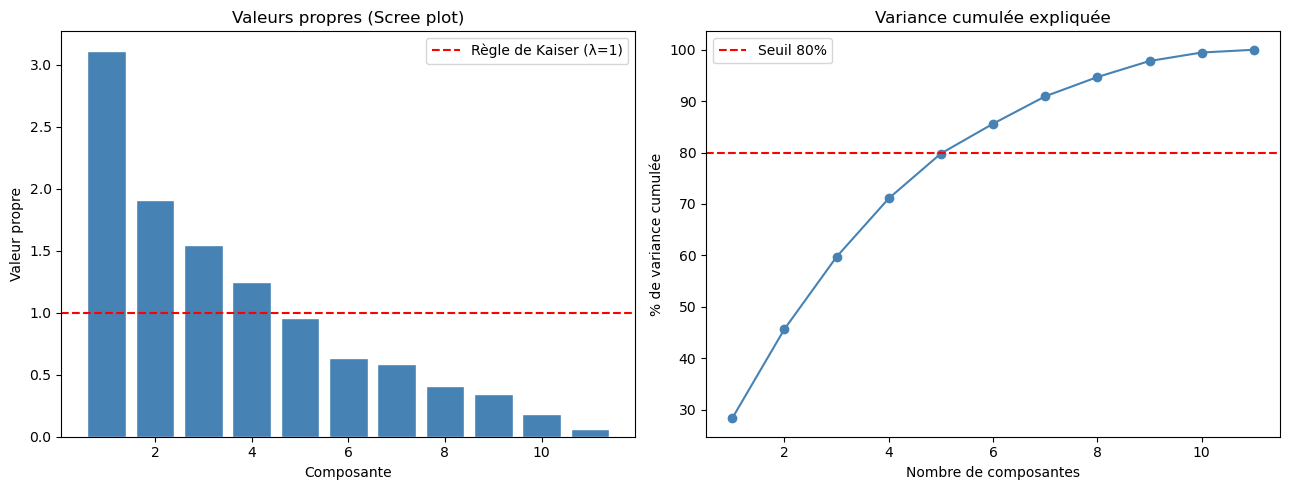

=== Tableau des valeurs propres ===
  Composante 1: λ=3.1146  |  % variance=28.29%  |  % cumulé=28.29%
  Composante 2: λ=1.9096  |  % variance=17.35%  |  % cumulé=45.64%
  Composante 3: λ=1.5485  |  % variance=14.07%  |  % cumulé=59.71%
  Composante 4: λ=1.2514  |  % variance=11.37%  |  % cumulé=71.08%
  Composante 5: λ=0.9616  |  % variance=8.74%  |  % cumulé=79.81%
  Composante 6: λ=0.6381  |  % variance=5.80%  |  % cumulé=85.61%
  Composante 7: λ=0.5873  |  % variance=5.34%  |  % cumulé=90.94%
  Composante 8: λ=0.4124  |  % variance=3.75%  |  % cumulé=94.69%
  Composante 9: λ=0.3442  |  % variance=3.13%  |  % cumulé=97.82%
  Composante 10: λ=0.1813  |  % variance=1.65%  |  % cumulé=99.46%
  Composante 11: λ=0.0590  |  % variance=0.54%  |  % cumulé=100.00%


In [2]:
# --- Scree plot (éboulis des valeurs propres) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(range(1, p+1), eigval, color='steelblue', edgecolor='white')
ax1.axhline(y=1, color='red', linestyle='--', label='Règle de Kaiser (λ=1)')
ax1.set_title("Valeurs propres (Scree plot)")
ax1.set_xlabel("Composante")
ax1.set_ylabel("Valeur propre")
ax1.legend()

ax2.plot(range(1, p+1), cumsum * 100, 'o-', color='steelblue')
ax2.axhline(y=80, color='red', linestyle='--', label='Seuil 80%')
ax2.set_title("Variance cumulée expliquée")
ax2.set_xlabel("Nombre de composantes")
ax2.set_ylabel("% de variance cumulée")
ax2.legend()
plt.tight_layout()
plt.savefig("acp_screeplot.png", dpi=150)
plt.show()

print("=== Tableau des valeurs propres ===")
for i in range(p):
    print(f"  Composante {i+1}: λ={eigval[i]:.4f}  |  "
          f"% variance={eigval_ratio[i]*100:.2f}%  |  "
          f"% cumulé={cumsum[i]*100:.2f}%")

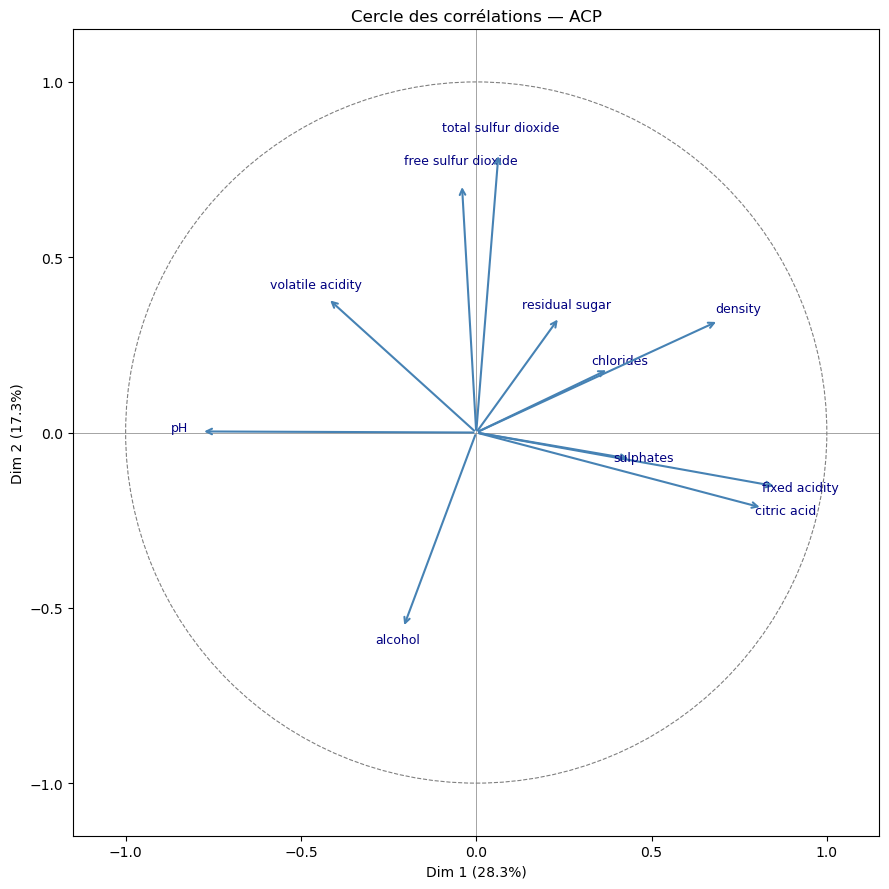

In [3]:
# --- Cercle des corrélations (axes 1 et 2) ---
coord = acp.components_.T * np.sqrt(eigval)

fig, ax = plt.subplots(figsize=(9, 9))
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=0.8)
ax.add_patch(circle)

for i, var in enumerate(X_cr.columns):
    ax.annotate("", xy=(coord[i, 0], coord[i, 1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color='steelblue', lw=1.5))
    ax.text(coord[i, 0] * 1.08, coord[i, 1] * 1.08, var,
            fontsize=9, ha='center', color='navy')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel(f"Dim 1 ({eigval_ratio[0]*100:.1f}%)")
ax.set_ylabel(f"Dim 2 ({eigval_ratio[1]*100:.1f}%)")
ax.set_title("Cercle des corrélations — ACP")
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig("acp_cercle_correlations.png", dpi=150)
plt.show()

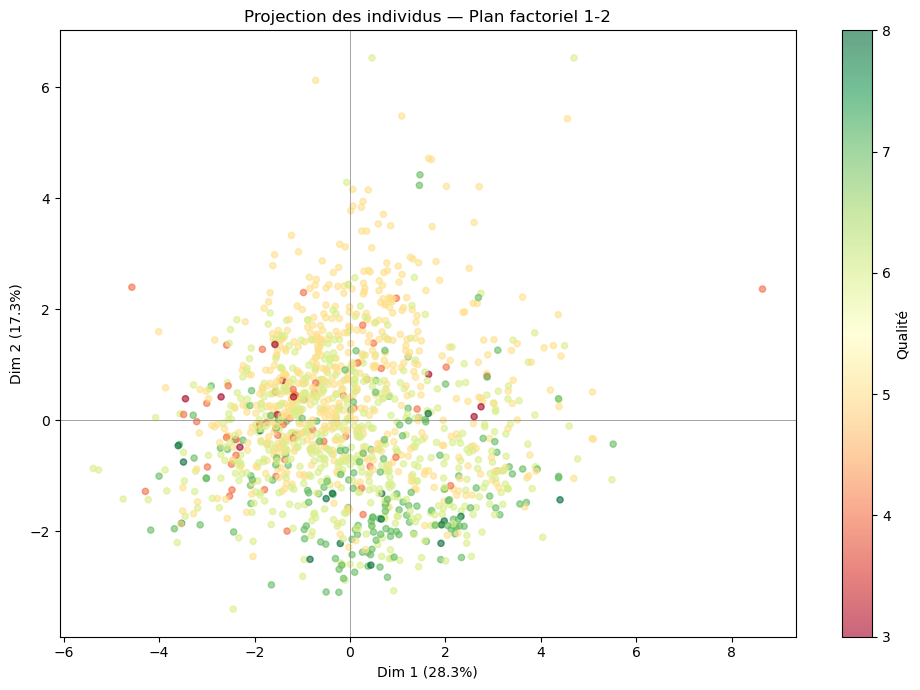

In [4]:
# --- Projection des individus sur le plan factoriel 1-2 ---
coord_ind = acp.transform(X_cr)
quality = pd.read_csv("df_prepared.csv")['quality']

plt.figure(figsize=(10, 7))
scatter = plt.scatter(coord_ind[:, 0], coord_ind[:, 1],
                      c=quality, cmap='RdYlGn', alpha=0.6, s=20)
plt.colorbar(scatter, label='Qualité')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel(f"Dim 1 ({eigval_ratio[0]*100:.1f}%)")
plt.ylabel(f"Dim 2 ({eigval_ratio[1]*100:.1f}%)")
plt.title("Projection des individus — Plan factoriel 1-2")
plt.tight_layout()
plt.savefig("acp_individus.png", dpi=150)
plt.show()



=== ANALYSE FACTORIELLE DES CORRESPONDANCES ===

=== Tableau de contingence ===
quality_cat  bon  mauvais  moyen
alcohol_cat                     
faible        17      441    179
moyen         71      179    251
élevé         96       20    105

Chi-2 = 388.54  |  p-valeur = 0.0000  |  ddl = 4
→ Les deux variables sont DÉPENDANTES (relation significative)

=== Profils lignes (%) ===
quality_cat   bon  mauvais  moyen
alcohol_cat                      
faible        2.7     69.2   28.1
moyen        14.2     35.7   50.1
élevé        43.4      9.0   47.5


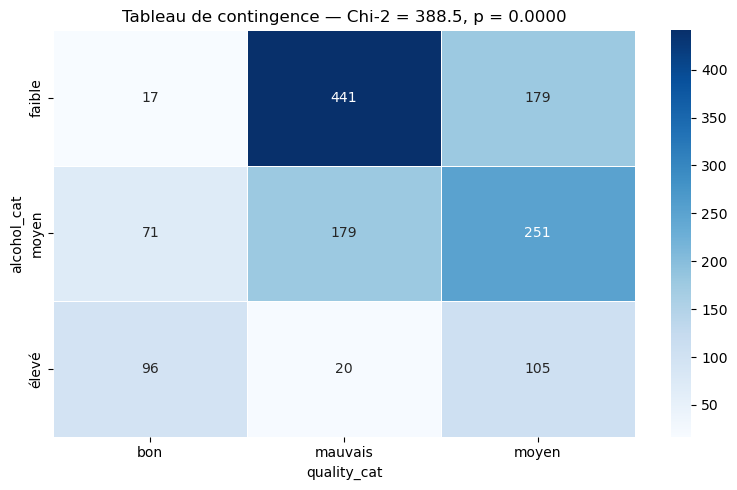

In [5]:
# === PARTIE 2 : AFC ===

print("\n\n=== ANALYSE FACTORIELLE DES CORRESPONDANCES ===")

df = pd.read_csv("df_prepared.csv")

# Discrétiser alcohol en 3 classes
df['alcohol_cat'] = pd.cut(df['alcohol'], bins=[8, 10, 11.5, 15],
                            labels=['faible', 'moyen', 'élevé'])

# Tableau de contingence : alcohol_cat × quality_cat
tableau = pd.crosstab(df['alcohol_cat'], df['quality_cat'])
print("\n=== Tableau de contingence ===")
print(tableau)

# Test du Chi-2
chi2, p_val, dof, expected = chi2_contingency(tableau)
print(f"\nChi-2 = {chi2:.2f}  |  p-valeur = {p_val:.4f}  |  ddl = {dof}")
if p_val < 0.05:
    print("→ Les deux variables sont DÉPENDANTES (relation significative)")
else:
    print("→ Les deux variables sont indépendantes")

# Profils lignes
profils_lignes = tableau.div(tableau.sum(axis=1), axis=0).round(3)
print("\n=== Profils lignes (%) ===")
print((profils_lignes * 100).round(1))

# Visualisation du tableau de contingence
plt.figure(figsize=(8, 5))
sns_import = __import__('seaborn')
sns_import.heatmap(tableau, annot=True, fmt='d', cmap='Blues',
                   linewidths=0.5)
plt.title(f"Tableau de contingence — Chi-2 = {chi2:.1f}, p = {p_val:.4f}")
plt.tight_layout()
plt.savefig("afc_contingence.png", dpi=150)
plt.show()